<h1>Sudoku</h1>

In [4]:
import matplotlib.pyplot as plt
import random, copy, math

<h4>Funkcja do wczytywania</h4>

In [5]:
def load_sudoku(filename):
    board = []
    
    with open(filename, 'r') as file:
        for line in file:
            line = line.strip()
            
                
            row = []
            for char in line:
                if char == 'x': row.append(0)
                else: row.append(int(char))
                    
            board.append(row)
            
    return board



<h4>Funkcja do wyświetlania</h4>

In [6]:
def draw_sudoku(initial_board, solved_board):
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    
    def draw_board(ax, board, base_board=None, title=""):
        ax.set_xlim(0, 9)
        ax.set_ylim(0, 9)
        ax.invert_yaxis()
        ax.set_aspect('equal')
        ax.axis('off')
        ax.set_title(title, fontsize=16)
        
        for i in range(10):
            linewidth = 2.5 if i % 3 == 0 else 0.5
            ax.plot([0, 9], [i, i], color='black', linewidth=linewidth)
            ax.plot([i, i], [0, 9], color='black', linewidth=linewidth)
            
        for row in range(9):
            for col in range(9):
                val = board[row][col]
                if val != 0:
                    text_color = 'black'
                    if base_board and base_board[row][col] == 0:
                        text_color = 'blue'
                        
                    ax.text(col + 0.5, row + 0.5, str(val), 
                            ha='center', va='center', fontsize=16, color=text_color)

    draw_board(axes[0], initial_board, title="Initial Board")
    
    draw_board(axes[1], solved_board, base_board=initial_board, title="Solved Board")
    
    plt.tight_layout()
    
    
    plt.show()
    plt.close(fig)


<h4>Wykres Energii</h4>

In [7]:
def plot_energy_and_temp(energies, temps=None):

    fig, ax1 = plt.subplots(figsize=(10, 6))

    color_energy = 'tab:blue'
    ax1.set_xlabel('Iteration (Step)')
    ax1.set_ylabel('Total Energy', color=color_energy, fontweight='bold')
    ax1.plot(energies, color=color_energy, alpha=0.9, linewidth=1)
    ax1.tick_params(axis='y', labelcolor=color_energy)
    ax1.grid(True, linestyle='--', alpha=0.5)

    if temps is not None:
        ax2 = ax1.twinx()  
        color_temp = 'tab:red'
        ax2.set_ylabel('Temperature', color=color_temp, fontweight='bold')
        ax2.plot(temps, color=color_temp, alpha=0.8, linewidth=2, linestyle=':')
        ax2.tick_params(axis='y', labelcolor=color_temp)
        plt.title('Energy Minimization and Cooling Schedule', fontsize=14)
    else:
        plt.title('Energy Minimization Over Time', fontsize=14)

    fig.tight_layout()  
    plt.show()


<h4>Generacja losowych kwadratów</h4>

In [8]:
def fill_blocks_and_get_movable(init_board):
    new_board = copy.deepcopy(init_board)
    movable_cells_by_block = [[] for _ in range(9)]
    
    for block_idx in range(9):
        start_row = (block_idx // 3) * 3
        start_col = (block_idx % 3) * 3
        
        fixed_numbers = set()
        empty_cells = []
        
        for r in range(start_row, start_row + 3):
            for c in range(start_col, start_col + 3):

                val = new_board[r][c]
                if val != 0: fixed_numbers.add(val)
                else: empty_cells.append((r, c))
                    
        all_numbers = set(range(1, 10))
        missing_numbers = list(all_numbers - fixed_numbers)
        
        random.shuffle(missing_numbers)
        

        for (r, c), num in zip(empty_cells, missing_numbers):
            new_board[r][c] = num
            movable_cells_by_block[block_idx].append((r, c))
            
    return new_board, movable_cells_by_block

<h4>Energia oraz tempertura</h4>

In [9]:
def calculate_total_energy(board):
    cost = 0
    
    for i in range(9):
        row_unique = len(set(board[i]))
        cost += (9 - row_unique)
        
        col_values = [board[r][i] for r in range(9)]
        col_unique = len(set(col_values))
        cost += (9 - col_unique)
        
    return cost

def calculate_partial_energy(board, block_idx):

    cost = 0
    
    start_row = (block_idx // 3) * 3
    start_col = (block_idx % 3) * 3
    
    for r in range(start_row, start_row + 3):
        row_unique = len(set(board[r]))
        cost += (9 - row_unique)
        
    for c in range(start_col, start_col + 3):
        col_values = [board[row][c] for row in range(9)]
        col_unique = len(set(col_values))
        cost += (9 - col_unique)
        
    return cost


def temp_exp(iteration, par, inital_temp):
    return inital_temp * (par ** iteration)

<h4>Główna funkcja</h4>

In [10]:
def solve_sudoku_sa(board, initial_temp, cooling_rate, min_temp, max_iterations):
    working_board = copy.deepcopy(board)
    

    working_board, movable_map = fill_blocks_and_get_movable(working_board)
    
    valid_blocks = [idx for idx in range(9) if len(movable_map[idx]) >= 2]
    
    if not valid_blocks:
        initial_cost = calculate_total_energy(working_board)
        return working_board, 0, [initial_cost]

    current_energy = calculate_total_energy(working_board)
    
    T = initial_temp
    iterations = 0
    energies = [current_energy]
    

    while T > min_temp and current_energy > 0 and iterations < max_iterations:
        iterations += 1
        
        block_idx = random.choice(valid_blocks)
        movable_cells = movable_map[block_idx]
        
        cell1, cell2 = random.sample(movable_cells, 2)
        r1, c1 = cell1
        r2, c2 = cell2
        
        old_partial_energy = calculate_partial_energy(working_board, block_idx)
        
        working_board[r1][c1], working_board[r2][c2] = working_board[r2][c2], working_board[r1][c1]
        
        new_partial_energy = calculate_partial_energy(working_board, block_idx)
        
        delta_E = new_partial_energy - old_partial_energy
        

        if delta_E < 0:
            current_energy += delta_E
        else:
            if random.random() < math.exp(-delta_E / T):
                current_energy += delta_E
            else:
                working_board[r1][c1], working_board[r2][c2] = working_board[r2][c2], working_board[r1][c1]
        
        energies.append(current_energy)
        
        T = temp_exp(iterations, cooling_rate,initial_temp)
        
    return working_board, iterations, energies

<h4>Sudoku Checker</h4>

In [11]:
def is_valid_sudoku(board):
    seen_rows = [set() for _ in range(9)]
    seen_cols = [set() for _ in range(9)]
    seen_boxes = [set() for _ in range(9)]

    for row in range(9):
        for col in range(9):
            num = board[row][col]

            if num == 0 or num == '.': continue

            box_index = (row // 3) * 3 + (col // 3)

            if num in seen_rows[row] or num in seen_cols[col] or num in seen_boxes[box_index]:
                return False

            seen_rows[row].add(num)
            seen_cols[col].add(num)
            seen_boxes[box_index].add(num)

    return True

--- Solving Easy Sudoku ---
The solution of sudoku was: True
SUCCESS! Found perfect solution in 17338 iterations.


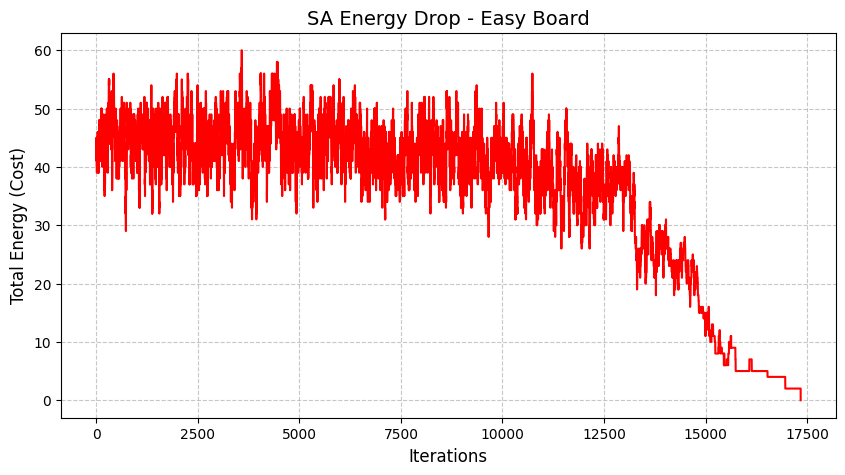

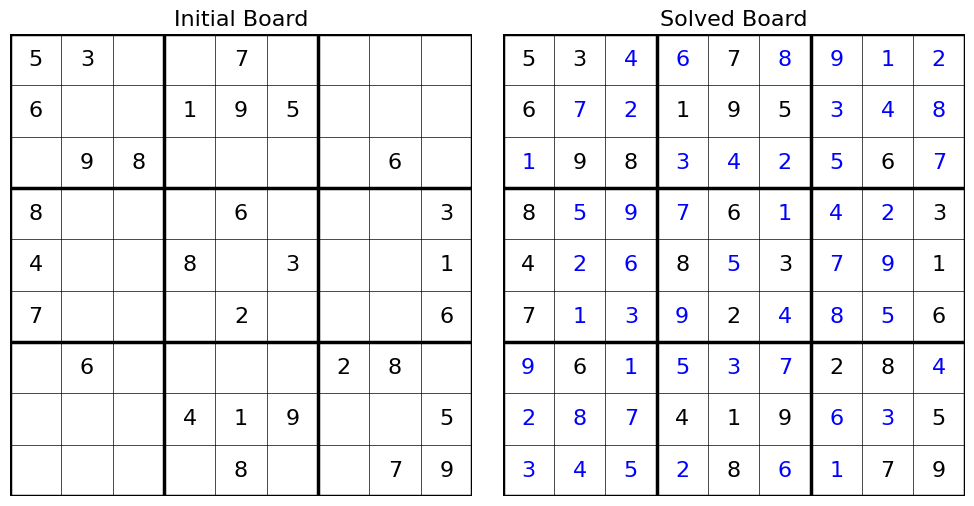



--- Solving Medium Sudoku ---
The solution of sudoku was: True
SUCCESS! Found perfect solution in 15750 iterations.


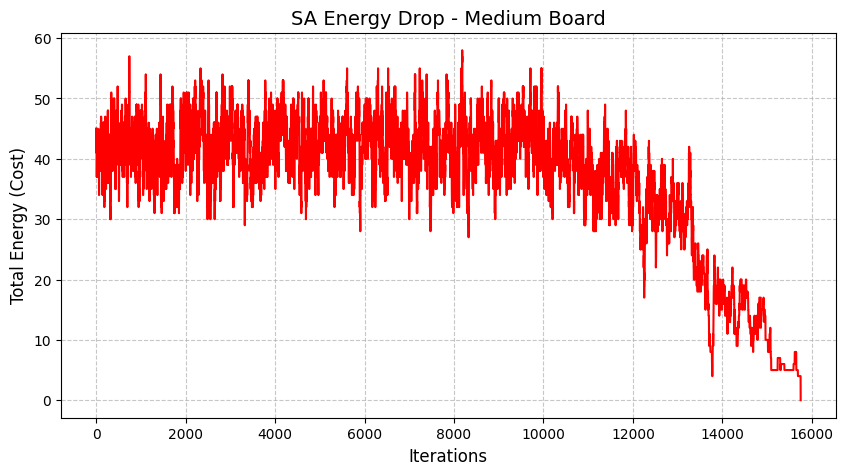

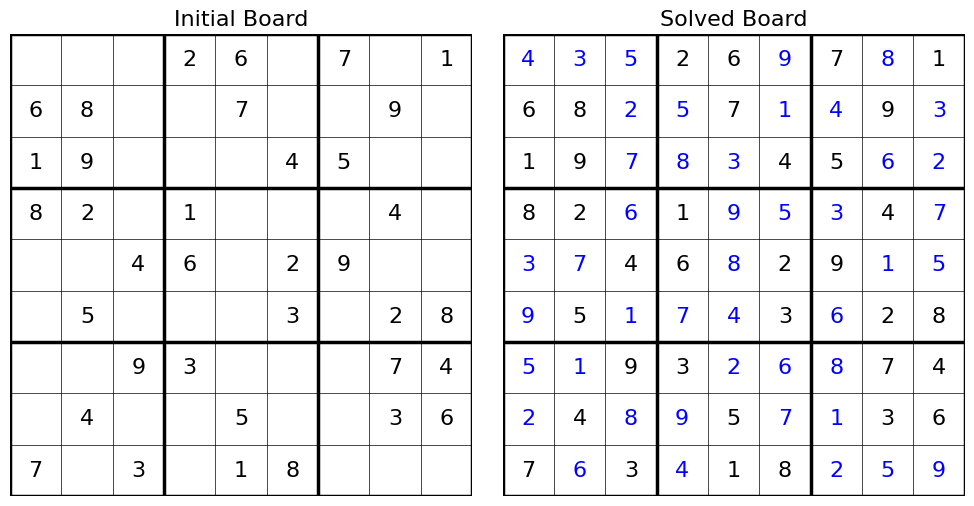



--- Solving Hard Sudoku ---
The solution of sudoku was: False
FAILED. Stuck at local minimum with energy 2 after 27625 iterations.


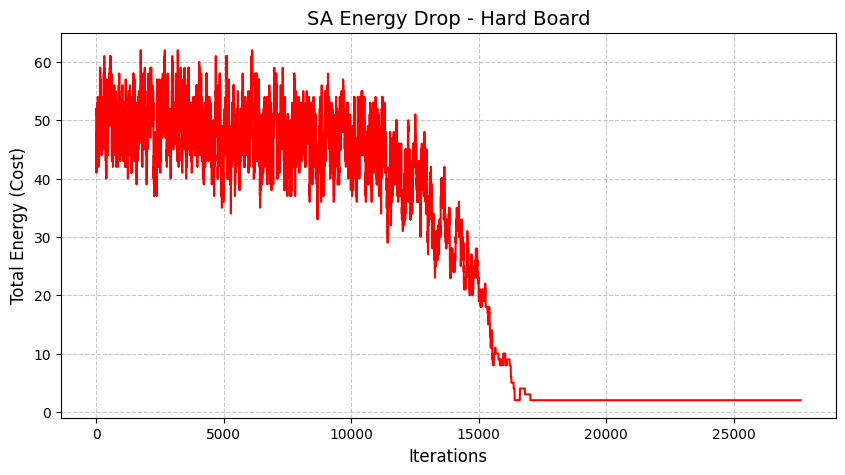

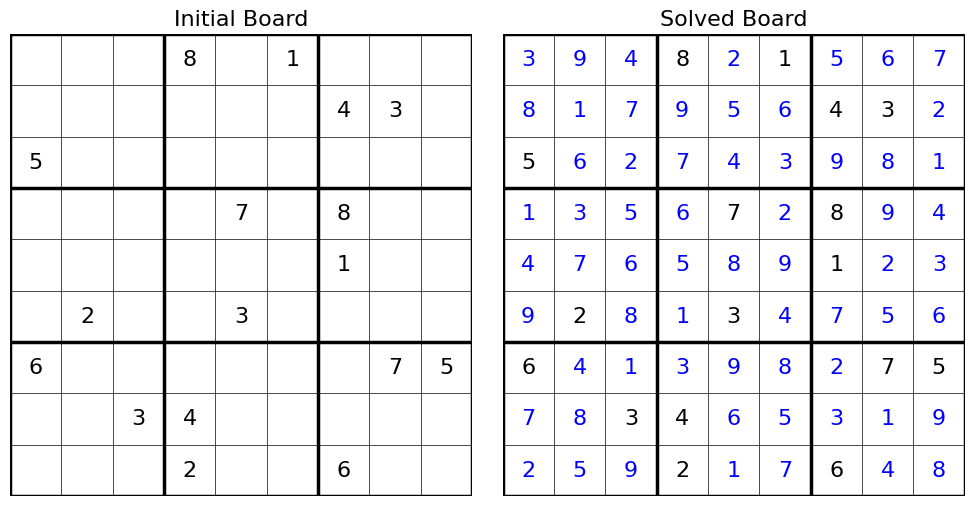

In [ ]:
def plot_energy_history(energies, title="Energy Drop during Simulated Annealing"):
    plt.figure(figsize=(10, 5))
    plt.plot(energies, color='red', linewidth=1.5)
    plt.title(title, fontsize=14)
    plt.xlabel("Iterations", fontsize=12)
    plt.ylabel("Total Energy (Cost)", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.show()

if __name__ == "__main__":
    # --- SAMPLE BOARDS ---
    # 0 represents empty cells ('x')
    
    # 1. Easy Board (many given numbers)
    easy_board = [
        [5, 3, 0, 0, 7, 0, 0, 0, 0],
        [6, 0, 0, 1, 9, 5, 0, 0, 0],
        [0, 9, 8, 0, 0, 0, 0, 6, 0],
        [8, 0, 0, 0, 6, 0, 0, 0, 3],
        [4, 0, 0, 8, 0, 3, 0, 0, 1],
        [7, 0, 0, 0, 2, 0, 0, 0, 6],
        [0, 6, 0, 0, 0, 0, 2, 8, 0],
        [0, 0, 0, 4, 1, 9, 0, 0, 5],
        [0, 0, 0, 0, 8, 0, 0, 7, 9]
    ]
    
    # 2. Medium Board
    medium_board = [
        [0, 0, 0, 2, 6, 0, 7, 0, 1],
        [6, 8, 0, 0, 7, 0, 0, 9, 0],
        [1, 9, 0, 0, 0, 4, 5, 0, 0],
        [8, 2, 0, 1, 0, 0, 0, 4, 0],
        [0, 0, 4, 6, 0, 2, 9, 0, 0],
        [0, 5, 0, 0, 0, 3, 0, 2, 8],
        [0, 0, 9, 3, 0, 0, 0, 7, 4],
        [0, 4, 0, 0, 5, 0, 0, 3, 6],
        [7, 0, 3, 0, 1, 8, 0, 0, 0]
    ]
    
    # 3. Hard Board (very few givens)
    hard_board = [
        [0, 0, 0, 8, 0, 1, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 4, 3, 0],
        [5, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 7, 0, 8, 0, 0],
        [0, 0, 0, 0, 0, 0, 1, 0, 0],
        [0, 2, 0, 0, 3, 0, 0, 0, 0],
        [6, 0, 0, 0, 0, 0, 0, 7, 5],
        [0, 0, 3, 4, 0, 0, 0, 0, 0],
        [0, 0, 0, 2, 0, 0, 6, 0, 0]
    ]

    test_cases = [
        ("Easy", easy_board),
        ("Medium", medium_board),
        ("Hard", hard_board)
    ]
    
    # Loop through each test case
    for difficulty, board in test_cases:
        print(f"--- Solving {difficulty} Sudoku ---")
        
        # Run the Simulated Annealing solver
        # We use a slower cooling rate (0.9995) to give the algorithm 
        # a better chance at escaping local minima for harder boards.
        solved_board, iterations, energies = solve_sudoku_sa(
            board, 
            initial_temp=1000.0, 
            cooling_rate=0.9995, 
            min_temp=0.001, 
            max_iterations=300000
        )
        
        final_energy = energies[-1]
        
        print(f"The solution of sudoku was: {is_valid_sudoku(solved_board)}")
        if final_energy == 0:
            print(f"SUCCESS! Found perfect solution in {iterations} iterations.")
        else:
            print(f"FAILED. Stuck at local minimum with energy {final_energy} after {iterations} iterations.")
            
        # Plot the energy graph (Close the window to proceed to the next board)
        plot_energy_history(energies, title=f"SA Energy Drop - {difficulty} Board")
        draw_sudoku(board, solved_board)
        
        # Uncomment below to also display the visual board comparison
        # result_image = get_sudoku_image(board, solved_board)
        # result_image.show()
        print("\n")

FAILED. Stuck at local minimum with energy 2 after 1000000 iterations.
False


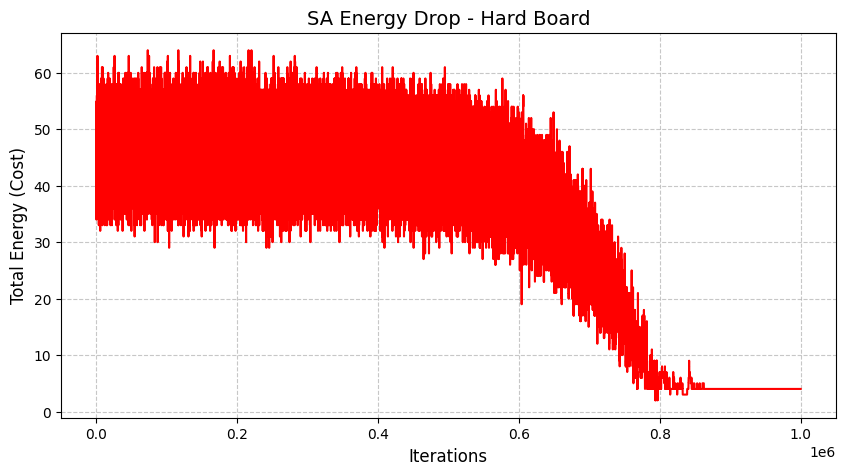

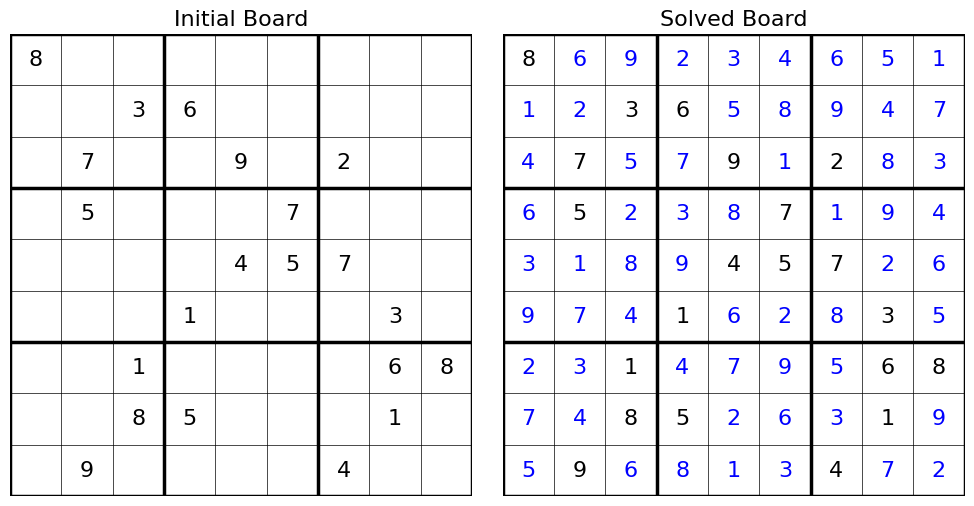

In [ ]:
board = load_sudoku("./Sudoku_files/hardest.txt")

solved_board, iterations, energies = solve_sudoku_sa(
    board, 
    initial_temp=1000.0, 
    cooling_rate=0.99999, 
    min_temp=0.001, 
    max_iterations=1000000
)

if energies[-1] == 0:
    print(f"SUCCESS! Found perfect solution in {iterations} iterations.")
else:
    print(f"FAILED. Stuck at local minimum with energy {final_energy} after {iterations} iterations.")
    
# Plot the energy graph (Close the window to proceed to the next board)
print(is_valid_sudoku(solved_board))
plot_energy_history(energies, title=f"SA Energy Drop - {difficulty} Board")
draw_sudoku(board, solved_board)